# Load and Export model
This is a notebook which shows how to load a pretrained model from a checkpoint and export it to the ONNX format as required by Marel.

In [1]:
import torch
import yaml
import numpy as np
from pathlib import Path
from omegaconf import OmegaConf
from scailes.utils import minimal_transform_resnext
from scailes.models.classifier import ScailesClassifier

# Load model checkpoint

In [2]:
model_path = Path("../models/version_11/")
model_ckpt = model_path / "checkpoints/epoch=659-step=10560.ckpt"
config = OmegaConf.load(model_path / "hparams.yaml")

# NB: `total_steps` kwarg no longer used. Only pass in config
model = ScailesClassifier.load_from_checkpoint(model_ckpt, config=config)

In [3]:
model.eval()

ScailesClassifier(
  (loss_function): FocalLoss()
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(128, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(in

# Exporting model

In [4]:
dummy_input = torch.randn(1, 3, 384, 512, device="cpu")

In [5]:
onnx_filename = model_path / "scale_classifier.onnx"
torch.onnx.export(
    model,
    dummy_input,
    onnx_filename,
    input_names=["input"],  # the model's input names
    output_names=["output"],  # the model's output names
    dynamic_axes={
        "input": {0: "batch_size"},  # variable length axes
        "output": {0: "batch_size"},
    },
)

# Testing exported model

In [12]:
onnx_filename = model_path / "scale_classifier.onnx"


In [11]:
import onnxruntime as ort
import pandas as pd
from PIL import Image

In [13]:
def to_numpy(tensor):
    return tensor.detach().cpu().numpy()


ort_session = ort.InferenceSession(onnx_filename)

In [14]:
# Taking a random image from the validation data
data_path = Path("../data/")
images_path = data_path / "images"
val_data = pd.read_csv(data_path / "validation.csv")
sample = val_data.sample(1)

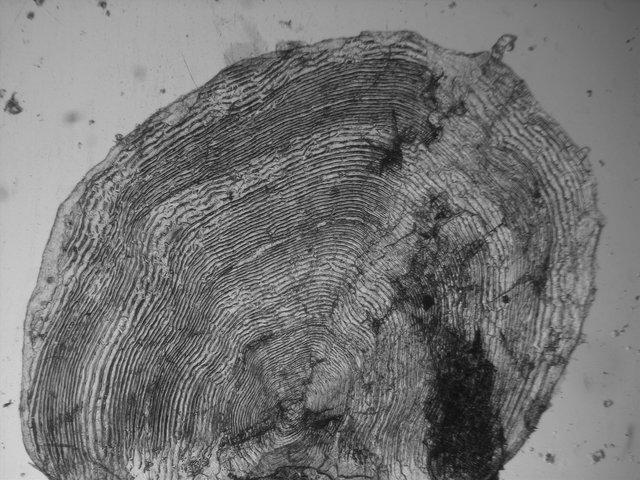

In [15]:
image = Image.open(images_path / sample.iloc[0].file_name)
image

In [16]:
tfm = minimal_transform_resnext()
input_tensor = tfm(image).unsqueeze(0)
print(input_tensor.shape)

torch.Size([1, 3, 384, 512])


In [17]:
output = ort_session.run(
    None,
    {"input": to_numpy(input_tensor)},
)[0]

In [18]:
torch_result = model(input_tensor).detach().numpy()
print(f"ONNX model output: {output}")
print(f"Torch model output: {torch_result}")

ONNX model output: [[ 11.216024 -11.897775]]
Torch model output: [[ 11.216016 -11.897764]]


In [19]:
np.allclose(output, to_numpy(model(input_tensor)))

True